# Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load Dataset

In [2]:
df = pd.read_csv("dataset_preprocessing.csv", encoding="utf-8-sig")

print("Jumlah data :", len(df))
print(df["label"].value_counts())
df.head()

Jumlah data : 2136
label
1    1068
0    1068
Name: count, dtype: int64


,judul,isi,tanggal,sumber,url,label,skor_distorsi,kata_distorsi,text,case_folding,cleaning,tokenisasi,stopword,stemming
0,"Negara Tetangga RI Ini Geram, Grok X Punya Elo...",Malaysia yang merupakan negara tetangga Indone...,"Selasa, 06 Jan 2026 14:15 WIB",Detik.com,https://inet.detik.com/cyberlife/d-8294118/neg...,1,1,dimanipulasi,"Negara Tetangga RI Ini Geram, Grok X Punya Elo...","negara tetangga ri ini geram, grok x punya elo...",negara tetangga ri ini geram grok punya elon m...,"['negara', 'tetangga', 'ri', 'ini', 'geram', '...","['negara', 'tetangga', 'ri', 'geram', 'grok', ...",negara tetangga ri geram grok punya elon musk ...
1,Grab Bantah Rumor Bakal Hengkang dari Indonesia,"Liputan6.com, Jakarta -Grab Indonesiamembantah...",2026-06-03T21:00:15+07:00,Liputan6.com,https://www.liputan6.com/bisnis/read/7631475/g...,0,0,NaN,Grab Bantah Rumor Bakal Hengkang dari Indonesi...,grab bantah rumor bakal hengkang dari indonesi...,grab bantah rumor bakal hengkang dari indonesi...,"['grab', 'bantah', 'rumor', 'bakal', 'hengkang...","['grab', 'bantah', 'rumor', 'bakal', 'hengkang...",grab bantah rumor bakal hengkang com grab indo...
2,Pegawai Bea Cukai Akui Simpan Uang Suap Impor ...,"JAKARTA, KOMPAS.com-Pelaksana pemeriksa Kantor...","Kompas.com, 3 Juni 2026, 17:07 WIB",Kompas.com,https://nasional.kompas.com/read/2026/06/03/17...,0,0,NaN,Pegawai Bea Cukai Akui Simpan Uang Suap Impor ...,pegawai bea cukai akui simpan uang suap impor ...,pegawai bea cukai akui simpan uang suap impor ...,"['pegawai', 'bea', 'cukai', 'akui', 'simpan', ...","['pegawai', 'bea', 'cukai', 'akui', 'simpan', ...",pegawai bea cukai aku simpan uang suap impor b...
3,"Sejarah Hajat Laut Pangandaran, Tradisi Syukur...","PANGANDARAN, KOMPAS.com— Tradisi Hajat Laut ke...",2026-06-02T12:14:36+00:00,Kompas.com,https://bandung.kompas.com/read/2026/06/02/191...,0,0,NaN,"Sejarah Hajat Laut Pangandaran, Tradisi Syukur...","sejarah hajat laut pangandaran, tradisi syukur...",sejarah hajat laut pangandaran tradisi syukur ...,"['sejarah', 'hajat', 'laut', 'pangandaran', 't...","['sejarah', 'hajat', 'laut', 'pangandaran', 't...",sejarah hajat laut pangandaran tradisi syukur ...
4,Purbaya: Pelemahan IHSG hanya syok sesaat,Jakarta (ANTARA) - Menteri Keuangan (Menkeu) P...,2026-01-28T17:27:48+07:00,Antaranews.com,https://www.antaranews.com/berita/5381766/purb...,1,2,syok,Purbaya: Pelemahan IHSG hanya syok sesaat Jaka...,purbaya: pelemahan ihsg hanya syok sesaat jaka...,purbaya pelemahan ihsg hanya syok sesaat jakar...,"['purbaya', 'pelemahan', 'ihsg', 'hanya', 'syo...","['purbaya', 'pelemahan', 'ihsg', 'syok', 'sesa...",purbaya lemah ihsg syok saat menteri uang menk...


# Analisis Semantik

In [5]:
semantic_lexicon = {
    "hiperbolik": [
        "geger", "heboh", "gempar", "dahsyat", "mencekam", "mengguncang",
        "menggemparkan", "menghebohkan", "mengerikan", "menakutkan", "mengejutkan",
        "dramatis", "mendadak", "sontak", "panik", "amburadul", "kisruh",
        "rusuh", "ricuh", "huru-hara", "kegaduhan",
    ],
    "emosional": [
        "murka", "meradang", "ngamuk", "amuk", "meluap", "emosi", "pitam",
        "memanas", "geram", "kemarahan", "terancam", "menjerit", "menangis",
        "menggila", "ketakutan", "pengkhianat", "pembohong", "penipu",
        "koruptor", "penjilat", "fitnah", "munafik", "bangsat", "brengsek",
    ],
    "provokatif": [
        "gagal total", "gagal parah", "tidak becus", "tidak kompeten",
        "tidak berguna", "tidak mampu", "habis-habisan", "tanpa ampun",
        "paling parah", "terburuk", "paling buruk", "paling jelek",
        "paling bodoh", "paling korup", "wajib tahu", "syok", "viral",
        "terbongkar", "terungkap", "terkuak", "terekspos", "membongkar",
        "mengungkap", "fakta mengejutkan", "fakta tersembunyi",
        "fakta mencengangkan", "netizen heboh", "netizen geram", "netizen murka",
        "semua orang", "seluruh warga", "sepanjang sejarah", "sepanjang masa",
        "pertama kali dalam sejarah", "direncanakan", "rekayasa", "skenario",
        "disembunyikan", "ditutupi", "dimanipulasi", "dalang", "persekongkolan",
        "sabotase", "nekat", "nekad", "biadab", "buas", "keji",
        "barbarian", "tidak berperikemanusiaan",
    ],
    "bias": [
        "katanya", "konon", "kabarnya", "disebut-sebut", "diisukan", "beredar",
        "diduga kuat", "diduga keras", "sumber terpercaya", "orang dalam",
        "sumber internal", "tanpa bukti", "tanpa konfirmasi", "tanpa verifikasi",
        "tersiar kabar", "santer terdengar", "berita bohong", "berita palsu",
        "fake news", "hoaks", "hoax", "sesat", "menyesatkan", "disesatkan",
        "ditipu", "dibohongi", "manipulasi informasi", "distorsi informasi",
        "informasi menyesatkan", "propaganda", "pencucian otak",
    ],
}

def extract_semantic_features(teks):
    teks_lower = str(teks).lower()
    total_kata = max(len(teks_lower.split()), 1)
    skor = {}

    for kategori, kata_list in semantic_lexicon.items():
        kata_urut = sorted(kata_list, key=lambda x: len(x.split()), reverse=True)
        cocok = sum(
            1 for kata in kata_urut
            if re.search(r"\b" + re.escape(kata) + r"\b", teks_lower)
        )
        skor[f"skor_{kategori}"] = round(cocok / total_kata, 4)

    skor["skor_distorsi"] = round(
        skor.get("skor_hiperbolik", 0) * 0.25
        + skor.get("skor_emosional", 0) * 0.25
        + skor.get("skor_provokatif", 0) * 0.30
        + skor.get("skor_bias", 0) * 0.20,
        4,
    )
    return pd.Series(skor)

# Ekstraksi Fitur Semantik

In [6]:
print("Menghitung fitur semantik...")
semantic_df = df["stemming"].apply(extract_semantic_features)
X_sem_all   = normalize(csr_matrix(semantic_df.values.astype(float)))
print("Shape Semantik:", semantic_df.shape)

Menghitung fitur semantik...
Shape Semantik: (2136, 5)


# Split Data & TF-IDF

In [7]:
X_text = df["stemming"].fillna("").astype(str)
y      = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"Data Train : {X_train_text.shape[0]}")
print(f"Data Test  : {X_test_text.shape[0]}")

# Fit TF-IDF hanya dari data training
tfidf_model = TfidfVectorizer(
    max_features = 25000,
    ngram_range  = (1, 3),
    sublinear_tf = True,
    min_df       = 1,
)
X_train_tfidf = tfidf_model.fit_transform(X_train_text)
X_test_tfidf  = tfidf_model.transform(X_test_text)

joblib.dump(tfidf_model, "tfidf_model.pkl")
print("tfidf_model berhasil disimpan!")

# Ambil fitur semantik sesuai index train/test
X_sem_train = X_sem_all[X_train_text.index]
X_sem_test  = X_sem_all[X_test_text.index]

# Gabungkan TF-IDF + Semantik
X_train_combined = hstack([X_train_tfidf, X_sem_train])
X_test_combined  = hstack([X_test_tfidf,  X_sem_test])

print(f"Shape Train Combined : {X_train_combined.shape}")
print(f"Shape Test Combined  : {X_test_combined.shape}")

Data Train : 1708
Data Test  : 428
tfidf_model berhasil disimpan!
Shape Train Combined : (1708, 25005)
Shape Test Combined  : (428, 25005)


# Training Model

In [9]:
model = ComplementNB(alpha=0.1)
model.fit(X_train_combined, y_train)

y_pred = model.predict(X_test_combined)
print("Test Accuracy :", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Test Accuracy : 84.11 %


Cross Validation

In [10]:
# Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_validate

print("Menjalankan 10-Fold Cross Validation...")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Gabungkan seluruh fitur (bukan hanya train)
X_all_combined = hstack([
    tfidf_model.transform(X_text),
    X_sem_all
])

cv_results = cross_validate(
    ComplementNB(alpha=0.1),
    X_all_combined,
    y,
    cv      = cv,
    scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
)

print("\n" + "="*55)
print(f"{'Fold':<8} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("="*55)
for i in range(10):
    print(f"Fold {i+1:<3} "
          f"{cv_results['test_accuracy'][i]*100:>9.2f}% "
          f"{cv_results['test_precision_macro'][i]*100:>9.2f}% "
          f"{cv_results['test_recall_macro'][i]*100:>9.2f}% "
          f"{cv_results['test_f1_macro'][i]*100:>9.2f}%")
print("="*55)
print(f"{'Rata-rata':<8} "
      f"{cv_results['test_accuracy'].mean()*100:>9.2f}% "
      f"{cv_results['test_precision_macro'].mean()*100:>9.2f}% "
      f"{cv_results['test_recall_macro'].mean()*100:>9.2f}% "
      f"{cv_results['test_f1_macro'].mean()*100:>9.2f}%")
print(f"{'Std Dev':<8} "
      f"{cv_results['test_accuracy'].std()*100:>9.2f}% "
      f"{cv_results['test_precision_macro'].std()*100:>9.2f}% "
      f"{cv_results['test_recall_macro'].std()*100:>9.2f}% "
      f"{cv_results['test_f1_macro'].std()*100:>9.2f}%")

Menjalankan 10-Fold Cross Validation...

Fold       Accuracy  Precision     Recall         F1
Fold 1       82.24%     82.53%     82.24%     82.20%
Fold 2       85.51%     85.52%     85.51%     85.51%
Fold 3       83.64%     83.65%     83.64%     83.64%
Fold 4       85.51%     85.59%     85.51%     85.51%
Fold 5       85.51%     85.59%     85.51%     85.51%
Fold 6       89.25%     89.67%     89.25%     89.22%
Fold 7       85.45%     85.84%     85.42%     85.40%
Fold 8       86.85%     86.91%     86.85%     86.85%
Fold 9       86.85%     86.91%     86.85%     86.85%
Fold 10      85.92%     85.96%     85.92%     85.91%
Rata-rata     85.68%     85.82%     85.67%     85.66%
Std Dev       1.78%      1.82%      1.78%      1.78%


# Evaluasi Model

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*50)
print(f"Test Accuracy : {round(accuracy * 100, 2)}%")
print("="*50)

print(classification_report(y_test, y_pred, target_names=["Normal", "Distorsi"]))


Test Accuracy : 84.11%
              precision    recall  f1-score   support

      Normal       0.85      0.83      0.84       214
    Distorsi       0.83      0.86      0.84       214

    accuracy                           0.84       428
   macro avg       0.84      0.84      0.84       428
weighted avg       0.84      0.84      0.84       428



In [19]:
# Tampilkan Contoh Hasil Prediksi Naive Bayes
print("="*70)
print("CONTOH HASIL PREDIKSI MODEL NAIVE BAYES")
print("="*70)

y_prob = model.predict_proba(X_test_combined)

hasil_prediksi = pd.DataFrame({
    "Judul"          : df.loc[X_test_text.index, "judul"].values,
    "Cuplikan Isi"   : df.loc[X_test_text.index, "isi"].str[:150].values,
    "Label Aktual"   : ["Normal" if l == 0 else "Distorsi" for l in y_test],
    "Label Prediksi" : ["Normal" if l == 0 else "Distorsi" for l in y_pred],
    "Confidence (%)" : [round(max(p) * 100, 2) for p in y_prob],
})

hasil_prediksi["Status"] = hasil_prediksi.apply(
    lambda r: "✓ Benar" if r["Label Aktual"] == r["Label Prediksi"] else "✗ Salah", axis=1
)

# Tampilkan 5 prediksi benar kelas Normal
print("\n[Prediksi BENAR - Kelas Normal]")
benar_normal = hasil_prediksi[
    (hasil_prediksi["Label Aktual"] == "Normal") &
    (hasil_prediksi["Status"] == "✓ Benar")
].head(5)
for _, r in benar_normal.iterrows():
    print(f"  Judul      : {r['Judul'][:70]}")
    print(f"  Isi        : {r['Cuplikan Isi'][:100]}...")
    print(f"  Aktual     : {r['Label Aktual']}")
    print(f"  Prediksi   : {r['Label Prediksi']}")
    print(f"  Confidence : {r['Confidence (%)']:.2f}%")
    print()

# Tampilkan 5 prediksi benar kelas Distorsi
print("\n[Prediksi BENAR - Kelas Distorsi]")
benar_distorsi = hasil_prediksi[
    (hasil_prediksi["Label Aktual"] == "Distorsi") &
    (hasil_prediksi["Status"] == "✓ Benar")
].head(5)
for _, r in benar_distorsi.iterrows():
    print(f"  Judul      : {r['Judul'][:70]}")
    print(f"  Isi        : {r['Cuplikan Isi'][:100]}...")
    print(f"  Aktual     : {r['Label Aktual']}")
    print(f"  Prediksi   : {r['Label Prediksi']}")
    print(f"  Confidence : {r['Confidence (%)']:.2f}%")
    print()

# Tampilkan 5 prediksi salah
print("\n[Prediksi SALAH]")
salah = hasil_prediksi[hasil_prediksi["Status"] == "✗ Salah"].head(5)
for _, r in salah.iterrows():
    print(f"  Judul      : {r['Judul'][:70]}")
    print(f"  Isi        : {r['Cuplikan Isi'][:100]}...")
    print(f"  Aktual     : {r['Label Aktual']}")
    print(f"  Prediksi   : {r['Label Prediksi']}")
    print(f"  Confidence : {r['Confidence (%)']:.2f}%")
    print()

CONTOH HASIL PREDIKSI MODEL NAIVE BAYES

[Prediksi BENAR - Kelas Normal]
  Judul      : 5 Zodiak yang Disebut Bahagia pada Juni 2026 Menurut Astrolog, Ada Ari
  Isi        : KOMPAS.com -Memasuki Juni 2026, sejumlah zodiak disebut akan mengalami perubahan positif dalam berba...
  Aktual     : Normal
  Prediksi   : Normal
  Confidence : 93.67%

  Judul      : Sampai Kapan Fenomena Bediding Bikin Menggigil? Ini Prediksi Pakar
  Isi        : Fenomenabedidingtengah terjadi di sejumlah wilayah Tanah Air. Sampai kapan fenomena ini akan membuat...
  Aktual     : Normal
  Prediksi   : Normal
  Confidence : 98.71%

  Judul      : Realisasi Lifting Minyak Baru Sentuh 576 Ribu Barel per 31 Mei 2026
  Isi        : Liputan6.com, Jakarta -Satuan Kerja KhususPelaksana Kegiatan Usaha Hulu Minyak danGas Bumi(SKK Migas...
  Aktual     : Normal
  Prediksi   : Normal
  Confidence : 99.47%

  Judul      : Kejagung geledah kantor BGN dan kediaman para tersangka pada kasus MBG
  Isi        : ANTARA - Direktur

# Visualisasi

Total data : 2136
Data train : 1708
Data test  : 428
label
1    1068
0    1068
Name: count, dtype: int64


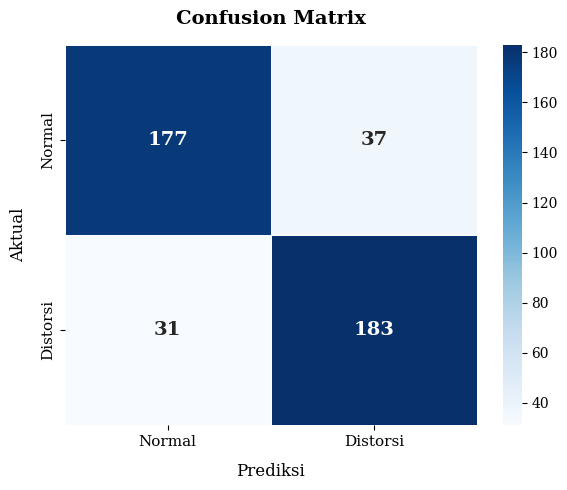

Disimpan: confusion_matrix.png


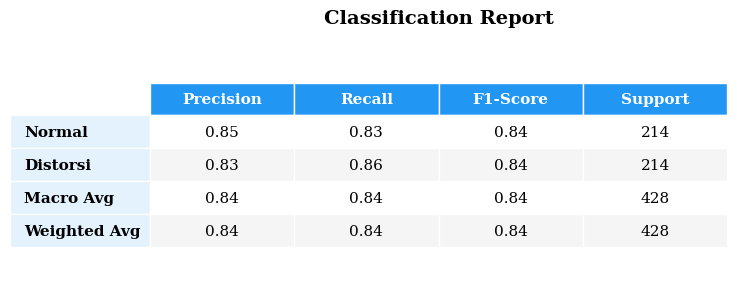

Disimpan: classification_report.png


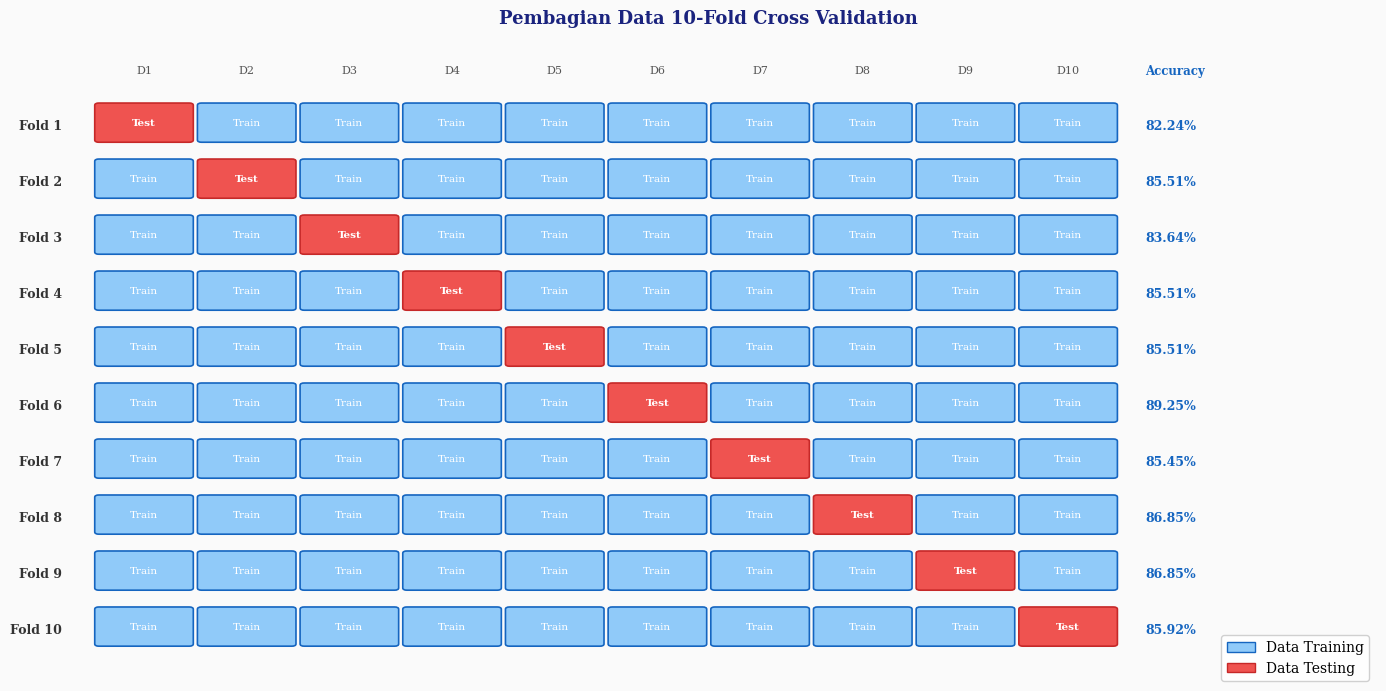

Disimpan: kfold_diagram.png


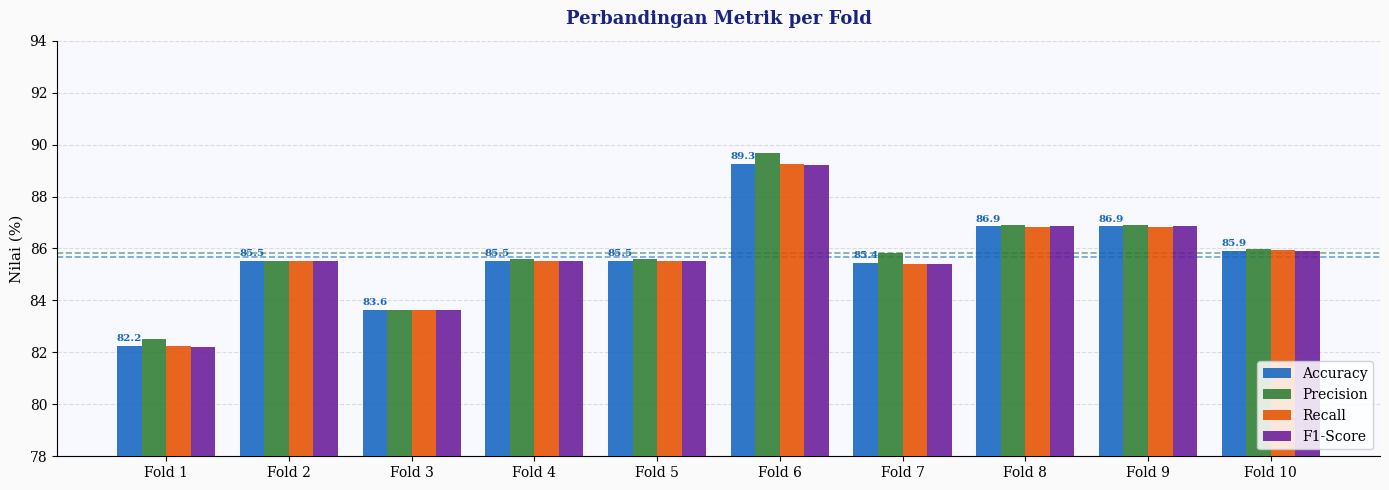

Disimpan: kfold_bar.png


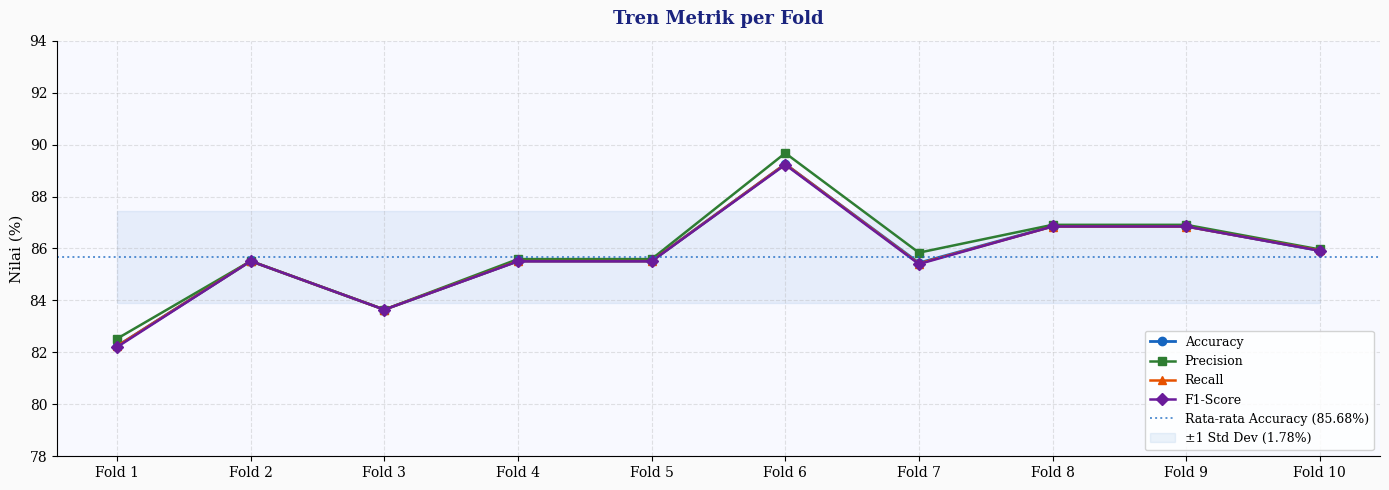

Disimpan: kfold_line.png


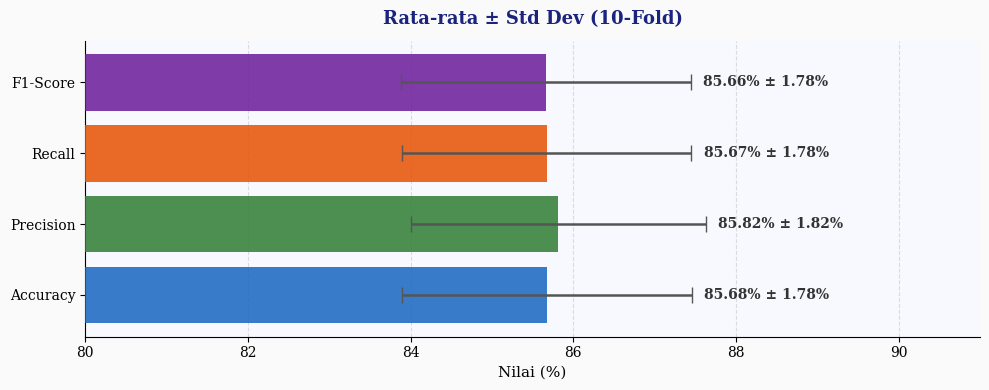

Disimpan: kfold_summary.png


In [18]:
cm = confusion_matrix(y_test, y_pred)

print(f"Total data : {len(df)}")
print(f"Data train : {X_train_text.shape[0]}")
print(f"Data test  : {X_test_text.shape[0]}")
print(df["label"].value_counts())

plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Distorsi"],
    yticklabels=["Normal", "Distorsi"],
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 14, "weight": "bold"}, ax=ax
)
ax.set_xlabel("Prediksi", fontsize=12, labelpad=10)
ax.set_ylabel("Aktual", fontsize=12, labelpad=10)
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan: confusion_matrix.png")

# Classification Report
report    = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[["0", "1", "macro avg", "weighted avg"]]
report_df.index = ["Normal", "Distorsi", "Macro Avg", "Weighted Avg"]
report_df = report_df[["precision", "recall", "f1-score", "support"]]
report_df[["precision", "recall", "f1-score"]] = report_df[["precision", "recall", "f1-score"]].round(2)
report_df["support"] = report_df["support"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")
table = ax.table(
    cellText=report_df.values,
    rowLabels=report_df.index,
    colLabels=["Precision", "Recall", "F1-Score", "Support"],
    cellLoc="center", loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2196F3")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#E3F2FD")
        cell.set_text_props(fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F5F5F5")
    cell.set_edgecolor("white")
ax.set_title("Classification Report", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("classification_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan: classification_report.png")

# ── Visualisasi K-Fold Cross Validation ──────────────────────────────────────
import numpy as np
import matplotlib.patches as mpatches

folds     = [f"Fold {i}" for i in range(1, 11)]
accuracy  = [r*100 for r in cv_results['test_accuracy']]
precision = [r*100 for r in cv_results['test_precision_macro']]
recall    = [r*100 for r in cv_results['test_recall_macro']]
f1        = [r*100 for r in cv_results['test_f1_macro']]
mean_acc  = cv_results['test_accuracy'].mean() * 100
mean_pre  = cv_results['test_precision_macro'].mean() * 100
mean_rec  = cv_results['test_recall_macro'].mean() * 100
mean_f1   = cv_results['test_f1_macro'].mean() * 100
stds      = [cv_results[f'test_{m}'].std()*100
             for m in ['accuracy','precision_macro','recall_macro','f1_macro']]

colors = {
    "accuracy" : "#1565C0", "precision": "#2E7D32",
    "recall"   : "#E65100", "f1"       : "#6A1B9A",
    "train"    : "#90CAF9", "test"     : "#EF5350",
}
n_folds = n_blocks = 10
block_w = 0.88; block_h = 0.62

# ── Gambar 1: Diagram K-Fold ─────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 7))
fig1.patch.set_facecolor("#FAFAFA")
ax1.set_xlim(-0.5, n_blocks+2.5); ax1.set_ylim(-0.5, n_folds+0.8)
ax1.axis("off"); ax1.set_facecolor("#F8F9FF")
ax1.set_title("Pembagian Data 10-Fold Cross Validation",
              fontsize=13, fontweight="bold", color="#1A237E", pad=14)
for fold_idx in range(n_folds):
    y_pos = n_folds - fold_idx - 1
    ax1.text(-0.3, y_pos+block_h/2, f"Fold {fold_idx+1}",
             va="center", ha="right", fontsize=9, fontweight="bold", color="#333")
    for block_idx in range(n_blocks):
        is_test = (block_idx == fold_idx)
        rect = mpatches.FancyBboxPatch(
            (block_idx+0.06, y_pos+0.06), block_w, block_h,
            boxstyle="round,pad=0.04",
            facecolor=colors["test"] if is_test else colors["train"],
            edgecolor="#C62828" if is_test else "#1565C0",
            linewidth=1.2, zorder=3)
        ax1.add_patch(rect)
        ax1.text(block_idx+0.06+block_w/2, y_pos+0.06+block_h/2,
                 "Test" if is_test else "Train",
                 ha="center", va="center", fontsize=7.5,
                 fontweight="bold" if is_test else "normal", color="white")
    ax1.text(n_blocks+0.25, y_pos+block_h/2, f"{accuracy[fold_idx]:.2f}%",
             va="center", ha="left", fontsize=9,
             color=colors["accuracy"], fontweight="bold")
for b in range(n_blocks):
    ax1.text(b+0.06+block_w/2, n_folds+0.3, f"D{b+1}",
             ha="center", va="center", fontsize=8, color="#555")
ax1.text(n_blocks+0.25, n_folds+0.3, "Accuracy",
         ha="left", va="center", fontsize=8.5, color=colors["accuracy"], fontweight="bold")
ax1.legend(handles=[
    mpatches.Patch(facecolor=colors["train"], edgecolor="#1565C0", linewidth=1, label="Data Training"),
    mpatches.Patch(facecolor=colors["test"],  edgecolor="#C62828", linewidth=1, label="Data Testing")],
    loc="lower right", fontsize=10, framealpha=0.9, bbox_to_anchor=(1.0, -0.02))
plt.tight_layout()
plt.savefig("kfold_diagram.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show(); print("Disimpan: kfold_diagram.png")

# ── Gambar 2: Bar Chart per Fold ─────────────────────────────────────────────
x = np.arange(len(folds)); width = 0.2
fig2, ax2 = plt.subplots(figsize=(14, 5))
fig2.patch.set_facecolor("#FAFAFA")
b1 = ax2.bar(x-1.5*width, accuracy,  width, label="Accuracy",  color=colors["accuracy"],  alpha=0.88, zorder=3)
b2 = ax2.bar(x-0.5*width, precision, width, label="Precision", color=colors["precision"], alpha=0.88, zorder=3)
b3 = ax2.bar(x+0.5*width, recall,    width, label="Recall",    color=colors["recall"],    alpha=0.88, zorder=3)
b4 = ax2.bar(x+1.5*width, f1,        width, label="F1-Score",  color=colors["f1"],        alpha=0.88, zorder=3)
ax2.axhline(mean_acc, color=colors["accuracy"],  linestyle="--", linewidth=1.2, alpha=0.6)
ax2.axhline(mean_pre, color=colors["precision"], linestyle="--", linewidth=1.2, alpha=0.6)
ax2.set_xticks(x); ax2.set_xticklabels(folds, fontsize=10)
ax2.set_ylim(78, 94); ax2.set_ylabel("Nilai (%)", fontsize=11)
ax2.set_title("Perbandingan Metrik per Fold", fontsize=13, fontweight="bold", color="#1A237E", pad=12)
ax2.legend(fontsize=10, loc="lower right", framealpha=0.85)
ax2.grid(axis="y", linestyle="--", alpha=0.4); ax2.set_facecolor("#F8F9FF")
for spine in ["top","right"]: ax2.spines[spine].set_visible(False)
for bar in b1:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{bar.get_height():.1f}", ha="center", va="bottom",
             fontsize=7.5, color=colors["accuracy"], fontweight="bold")
plt.tight_layout()
plt.savefig("kfold_bar.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show(); print("Disimpan: kfold_bar.png")

# ── Gambar 3: Line Chart Tren ─────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 5))
fig3.patch.set_facecolor("#FAFAFA")
ax3.plot(folds, accuracy,  marker="o", color=colors["accuracy"],  linewidth=2,   label="Accuracy")
ax3.plot(folds, precision, marker="s", color=colors["precision"], linewidth=1.8, label="Precision")
ax3.plot(folds, recall,    marker="^", color=colors["recall"],    linewidth=1.8, label="Recall")
ax3.plot(folds, f1,        marker="D", color=colors["f1"],        linewidth=1.8, label="F1-Score")
ax3.axhline(mean_acc, color=colors["accuracy"], linestyle=":", linewidth=1.4, alpha=0.7,
            label=f"Rata-rata Accuracy ({mean_acc:.2f}%)")
ax3.fill_between(range(len(folds)), [mean_acc-stds[0]]*10, [mean_acc+stds[0]]*10,
                 alpha=0.08, color=colors["accuracy"], label=f"±1 Std Dev ({stds[0]:.2f}%)")
ax3.set_xticks(range(len(folds))); ax3.set_xticklabels(folds, fontsize=10)
ax3.set_ylim(78, 94); ax3.set_ylabel("Nilai (%)", fontsize=11)
ax3.set_title("Tren Metrik per Fold", fontsize=13, fontweight="bold", color="#1A237E", pad=12)
ax3.legend(fontsize=9, loc="lower right", framealpha=0.85)
ax3.grid(linestyle="--", alpha=0.35); ax3.set_facecolor("#F8F9FF")
for spine in ["top","right"]: ax3.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("kfold_line.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show(); print("Disimpan: kfold_line.png")

# ── Gambar 4: Summary Rata-rata ───────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 4))
fig4.patch.set_facecolor("#FAFAFA")
metrics    = ["Accuracy", "Precision", "Recall", "F1-Score"]
means      = [mean_acc, mean_pre, mean_rec, mean_f1]
bar_colors = [colors["accuracy"], colors["precision"], colors["recall"], colors["f1"]]
bars = ax4.barh(metrics, means, xerr=stds, color=bar_colors, alpha=0.85,
                error_kw=dict(ecolor="#555", capsize=6, linewidth=1.8), zorder=3)
ax4.set_xlim(80, 91); ax4.set_xlabel("Nilai (%)", fontsize=11)
ax4.set_title("Rata-rata ± Std Dev (10-Fold)", fontsize=13, fontweight="bold", color="#1A237E", pad=12)
ax4.grid(axis="x", linestyle="--", alpha=0.4); ax4.set_facecolor("#F8F9FF")
for spine in ["top","right"]: ax4.spines[spine].set_visible(False)
for bar, mean, std in zip(bars, means, stds):
    ax4.text(mean+std+0.15, bar.get_y()+bar.get_height()/2,
             f"{mean:.2f}% ± {std:.2f}%",
             va="center", fontsize=10, fontweight="bold", color="#333")
plt.tight_layout()
plt.savefig("kfold_summary.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show(); print("Disimpan: kfold_summary.png")

# Simpan Model

In [9]:
joblib.dump(model, "model_distorsi.pkl")
print("Model berhasil disimpan!")

Model berhasil disimpan!
